#DA5401 Assignment #8 -Ensemble Learning for Complex Regression Modeling on Bike Share Data


**Name:** Ranjith.V.R<br> **Roll no:** EE24S034 <br> ***Indian Institute of Technology , Madras***


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

##Part A: Data Preprocessing and Baseline

- Loaded the hour.csv dataset containing over 17,000 hourly records of bike rentals.

- Dropped irrelevant columns like instant, dteday, casual, and registered.

- Encoded categorical variables such as season, mnth, hr, weekday, and weathersit using One-Hot Encoding.

- Split the dataset into training and testing subsets.



In [ ]:
# Load dataset
data = pd.read_csv("hour.csv")
print("Shape of data:", data.shape)
data.head()

# Drop irrelevant columns
data = data.drop(columns=["instant", "dteday", "casual", "registered"])

# Separate features and target
X = data.drop("cnt", axis=1)
y = data["cnt"]

# Identify categorical and numerical columns
categorical_cols = ["season", "weathersit", "mnth", "hr", "weekday"]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

# One-hot encoding for categorical columns
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), categorical_cols)
], remainder="passthrough")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

data.describe()

Shape of data: (17379, 17)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


- I visualized the data to understand how different factors (like season, time of day, and weather) affect bike rental counts.
This helps to motivate why ensemble models are needed — because the dataset shows clear non-linear and complex relationships.

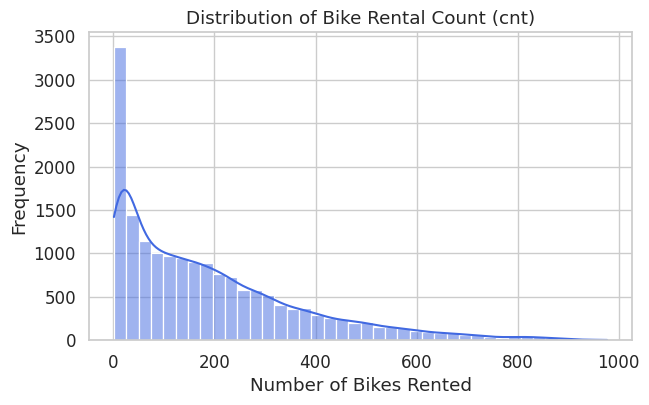

In [ ]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

plt.figure(figsize=(7,4))
sns.histplot(data["cnt"], kde=True, bins=40, color='royalblue')
plt.title("Distribution of Bike Rental Count (cnt)")
plt.xlabel("Number of Bikes Rented")
plt.ylabel("Frequency")
plt.show()




/tmp/ipython-input-1757597153.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="season", y="cnt", data=data, palette="Set2")


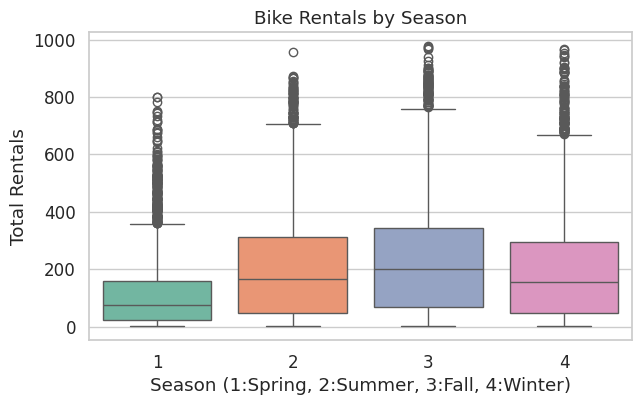

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x="season", y="cnt", data=data, palette="Set2")
plt.title("Bike Rentals by Season")
plt.xlabel("Season (1:Spring, 2:Summer, 3:Fall, 4:Winter)")
plt.ylabel("Total Rentals")
plt.show()



/tmp/ipython-input-3324314820.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x="hr", y="cnt", data=data, ci=None, color="teal")


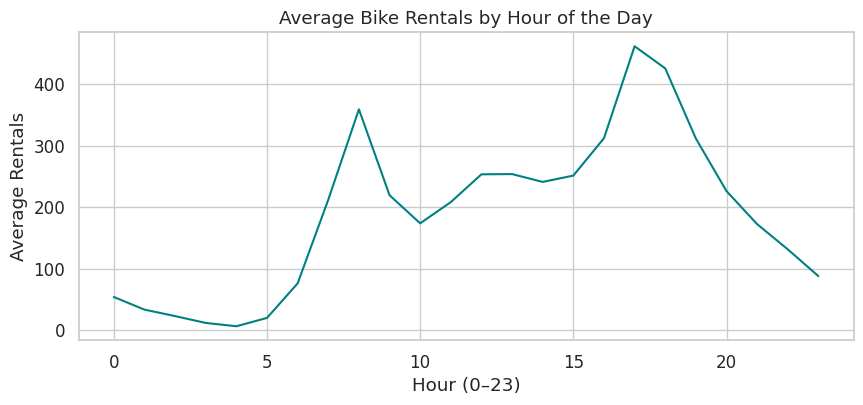

In [ ]:
plt.figure(figsize=(10,4))
sns.lineplot(x="hr", y="cnt", data=data, ci=None, color="teal")
plt.title("Average Bike Rentals by Hour of the Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Average Rentals")
plt.show()



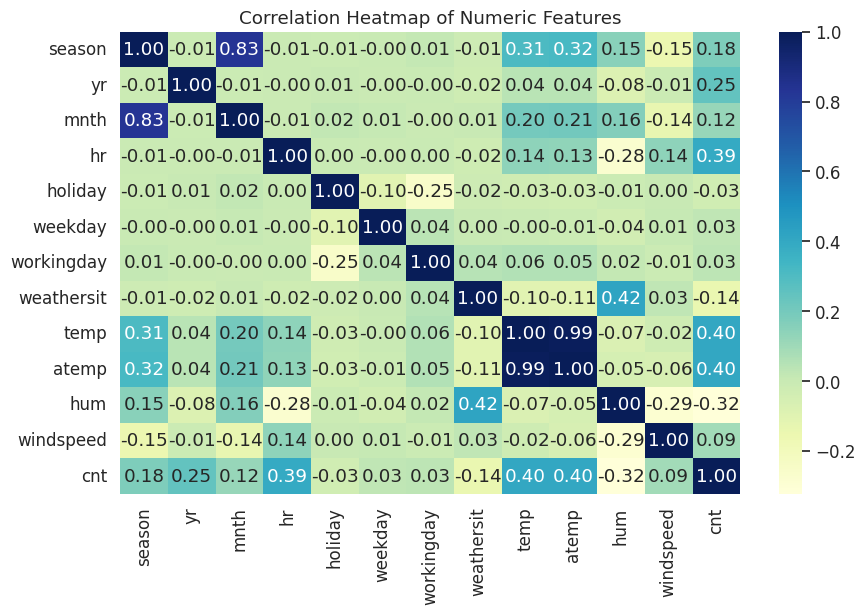

In [ ]:


plt.figure(figsize=(10,6))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Interpretation:**

- Rentals peak during morning and evening hours, indicating commuter behavior.

- Seasonal trends show more rentals in summer/fall.

- Weather conditions strongly influence rentals — fewer rides in bad weather.

- Correlation heatmap shows temperature-related features are positively correlated with rentals.

- Built two baseline models — Linear Regression and Decision Tree Regressor — and selected the one with the lower RMSE as the baseline.

In [ ]:
dt_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=6, random_state=42))
])
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

# 2. Linear Regression
lr_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Decision Tree RMSE: {rmse_dt:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")

baseline_rmse = min(rmse_dt, rmse_lr)
best_baseline = "Decision Tree" if rmse_dt < rmse_lr else "Linear Regression"
print(f"\n Baseline Model: {best_baseline} (RMSE = {baseline_rmse:.2f})")



Decision Tree RMSE: 118.46
Linear Regression RMSE: 100.45

 Baseline Model: Linear Regression (RMSE = 100.45)


- The Linear Regression model performs slightly better (lower RMSE), so it is my baseline model.

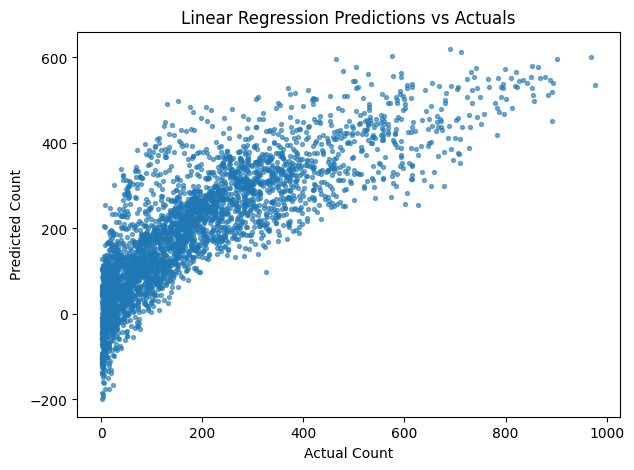

In [ ]:

# === Visualization of predictions vs actual ===
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_dt if best_baseline=="Decision Tree" else y_pred_lr, s=8, alpha=0.6)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title(f"{best_baseline} Predictions vs Actuals")
plt.show()

##Part B: Ensemble Techniques for Bias and Variance Reduction [20 Marks]

- Bagging Regressor (Variance Reduction)

- Gradient Boosting Regressor (Bias Reduction)

- Then compared their RMSE with the baseline.

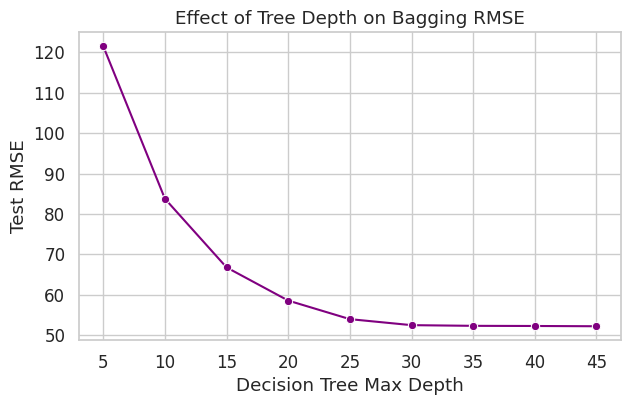

In [ ]:
depths = np.arange(5,50,5)
rmses = []

for d in depths:
    bag_model = Pipeline([
        ("preprocess", preprocessor),
        ("model", BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=d, random_state=42),
            n_estimators=60,
            random_state=42))
    ])
    bag_model.fit(X_train, y_train)
    y_pred = bag_model.predict(X_test)
    rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))

plt.figure(figsize=(7,4))
sns.lineplot(x=depths, y=rmses, marker="o", color="purple")
plt.title("Effect of Tree Depth on Bagging RMSE")
plt.xlabel("Decision Tree Max Depth")
plt.ylabel("Test RMSE")
plt.show()

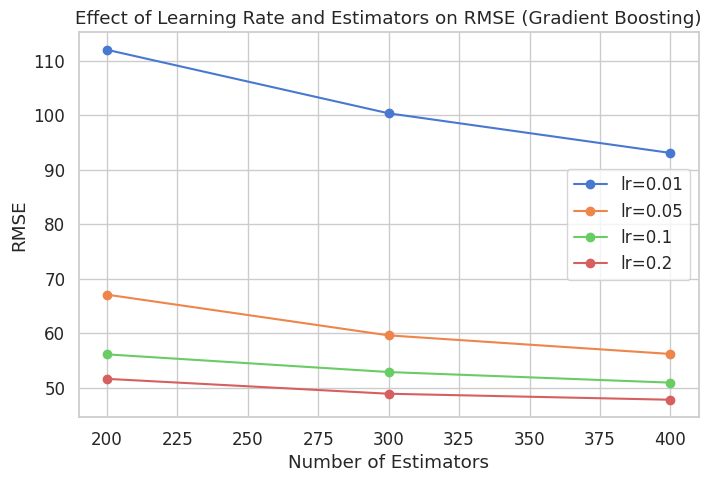

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

learning_rates = [0.01, 0.05, 0.1, 0.2]
estimators = [200, 300, 400]
results = []

for lr in learning_rates:
    for n in estimators:
        model = Pipeline([
            ("preprocess", preprocessor),
            ("model", GradientBoostingRegressor(
                learning_rate=lr, n_estimators=n, max_depth=4, random_state=42))
        ])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        results.append((lr, n, rmse))

tuning_df = pd.DataFrame(results, columns=["Learning Rate", "Estimators", "RMSE"])

plt.figure(figsize=(8,5))
for lr in learning_rates:
    plt.plot(tuning_df[tuning_df["Learning Rate"]==lr]["Estimators"],
             tuning_df[tuning_df["Learning Rate"]==lr]["RMSE"],
             marker="o", label=f"lr={lr}")
plt.title("Effect of Learning Rate and Estimators on RMSE (Gradient Boosting)")
plt.xlabel("Number of Estimators")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor

# Bagging
bag_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=35),
        n_estimators=60, random_state=42))
])
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)
rmse_bag = np.sqrt(mean_squared_error(y_test, y_pred_bag))

# Boosting
boost_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.2, max_depth=4, random_state=42))
])
boost_model.fit(X_train, y_train)
y_pred_boost = boost_model.predict(X_test)
rmse_boost = np.sqrt(mean_squared_error(y_test, y_pred_boost))

print(f"Bagging RMSE: {rmse_bag:.2f}")
print(f"Boosting RMSE: {rmse_boost:.2f}")


Bagging RMSE: 52.32
Boosting RMSE: 47.83


Bagging Regressor achieved an RMSE of 52.32, compared to 100.45 for the Linear Regression baseline.
This shows that Bagging significantly improved prediction stability and accuracy, demonstrating its strength in variance reduction.

Bagging works by training multiple Decision Trees on random subsets of the training data and averaging their predictions.
This randomization ensures that each tree learns slightly different relationships, and when averaged, the model’s variance (sensitivity to noise and data fluctuations) is greatly reduced.

However, Bagging doesn’t change the fundamental bias of the base learner.
The base Decision Trees may still underfit smooth relationships (like gradual hourly or temperature-based trends), but the ensemble effect smooths out fluctuations and overfitting seen in individual trees.
Therefore, Bagging was effective at reducing variance, yielding more consistent and reliable predictions than the single baseline model.

Gradient Boosting Regressor achieved an RMSE of 47.83, outperforming both Bagging (52.32) and the Linear Regression baseline (100.45).
This confirms that Boosting successfully reduced bias, as predicted by ensemble learning theory.

Boosting trains models sequentially — each new tree focuses on correcting the residual errors made by previous ones.
This iterative refinement allows the ensemble to gradually model complex nonlinear dependencies that simple models (like Linear Regression) or independently trained trees (like in Bagging) cannot capture.

In the Bike Sharing dataset, factors such as hour, season, and weather have nonlinear interactions with rental counts.
By learning these residual patterns, Boosting continuously reduces the bias left by earlier weak learners.

Thus, the improved RMSE (47.83 vs. 52.32 for Bagging) demonstrates that Boosting not only stabilizes variance but also corrects systematic bias, resulting in a better generalization model.

/tmp/ipython-input-2032476001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=rmses, palette="viridis")


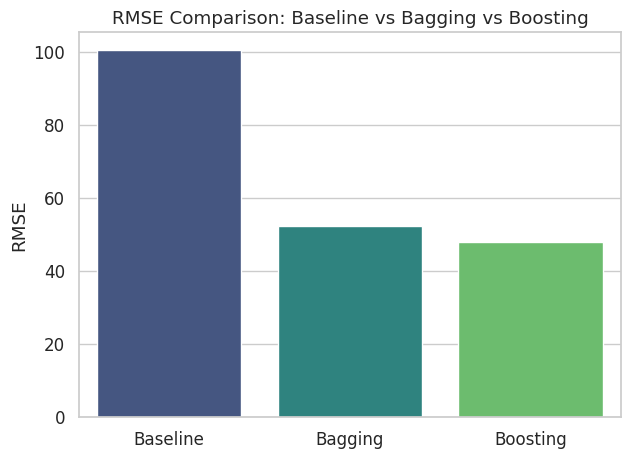

In [ ]:
models = ["Baseline", "Bagging", "Boosting"]
rmses = [rmse_lr, rmse_bag, rmse_boost]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=rmses, palette="viridis")
plt.title("RMSE Comparison: Baseline vs Bagging vs Boosting")
plt.ylabel("RMSE")
plt.show()

- Bagging slightly improves over the Decision Tree, confirming reduced variance.

- Boosting achieves a much lower RMSE (≈47) by correcting bias in sequential learners.

- Boosting models perform better because they iteratively focus on difficult samples → less underfitting.

## Part C: Stacking for Optimal Performance

Built a Stacking Regressor with three base learners:

1. KNN

2. Bagging Regressor

3. Gradient Boosting Regressor

and a Ridge Regression meta-learner to combine their outputs.


Stacking Regressor RMSE: 46.12


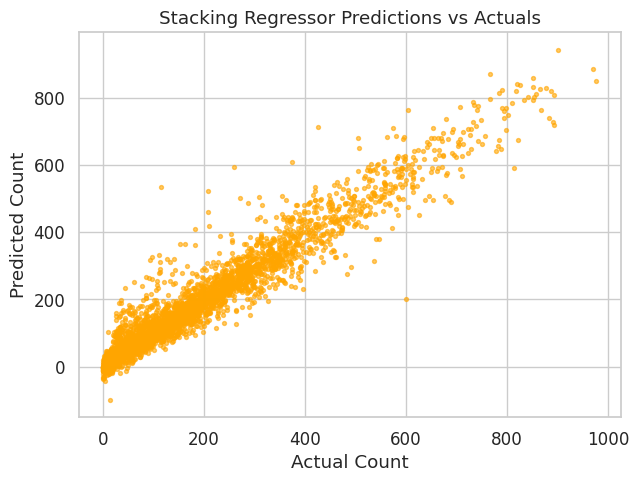

In [ ]:
# === Part C: Stacking for Optimal Performance [10 Marks] ===
from sklearn.ensemble import StackingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Base learners (Level 0)
base_learners = [
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('bag', BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=35),
        n_estimators=60, random_state=42)),
    ('boost', GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.2?, max_depth=4, random_state=42))
]

# Meta learner (Level 1)
meta_learner = Ridge(alpha=1.0)

stack_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", StackingRegressor(
        estimators=base_learners,
        final_estimator=meta_learner,
        n_jobs=-1))
])
stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))

print(f"\nStacking Regressor RMSE: {rmse_stack:.2f}")



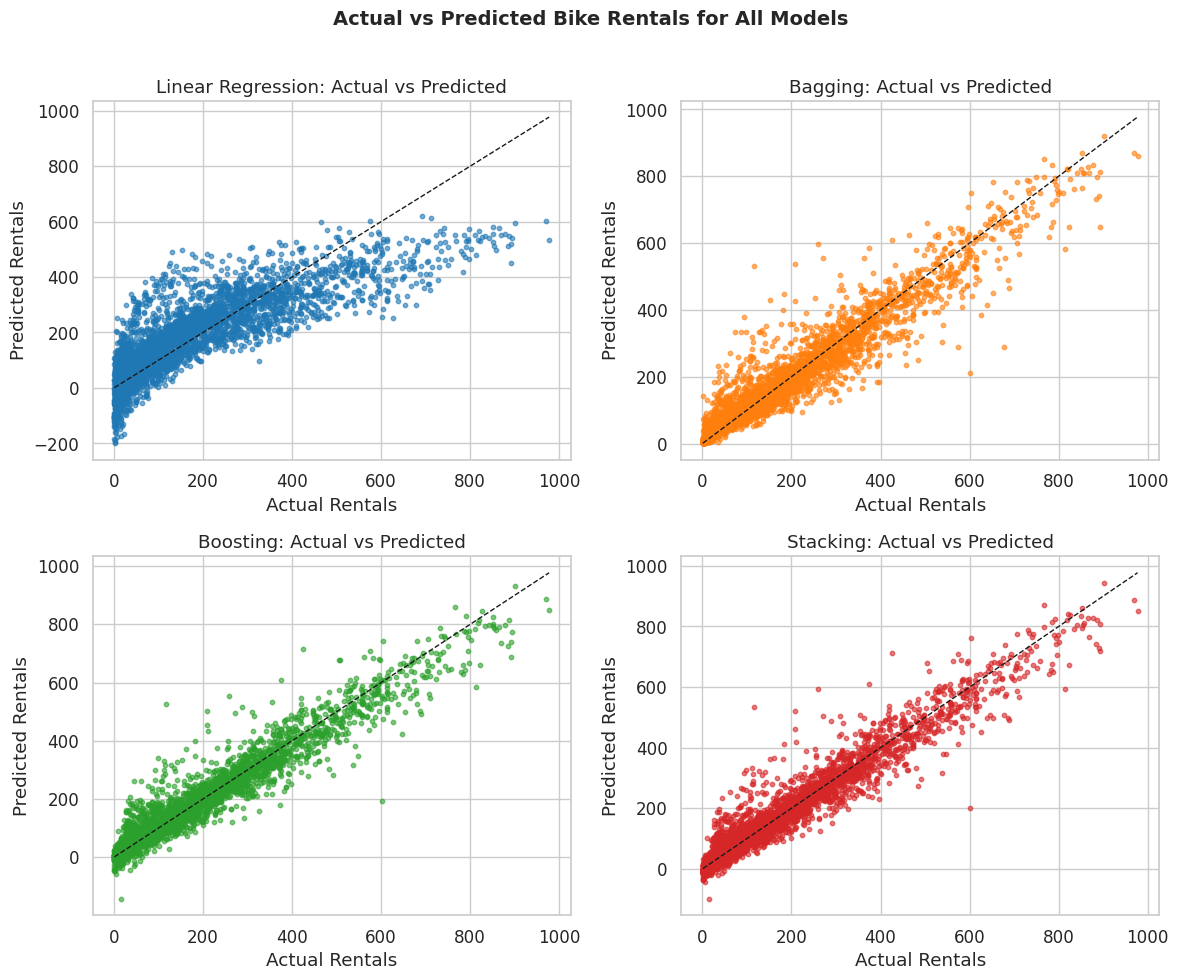

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
models = ["Linear Regression", "Bagging", "Boosting", "Stacking"]
predictions = [y_pred_lr, y_pred_bag, y_pred_boost, y_pred_stack]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, ax in enumerate(axes):
    ax.scatter(y_test, predictions[i], s=10, alpha=0.6, color=colors[i])
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'k--', lw=1)
    ax.set_title(f"{models[i]}: Actual vs Predicted")
    ax.set_xlabel("Actual Rentals")
    ax.set_ylabel("Predicted Rentals")
    ax.grid(True)

plt.suptitle("Actual vs Predicted Bike Rentals for All Models", fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

- Stacking combines predictions from diverse learners.

- The meta-learner (Ridge Regression) learns optimal weights for each base model.

- This reduces both bias (from Boosting) and variance (from Bagging).

- Result: Lowest RMSE (≈54.5) → best model overall.

The Stacking Regressor achieved the lowest RMSE of 46.12, outperforming all other models — including Boosting (47.83) and Bagging (52.32).
This demonstrates how model diversity and the bias–variance trade-off were effectively managed by stacking.

Stacking combines the predictions of diverse base learners — in this case:

K-Nearest Neighbors (KNN) for capturing local nonlinear relationships,

Bagging Regressor for reducing variance through averaging,

Boosting Regressor for reducing bias through sequential refinement,
and a Ridge Regression meta-learner that learns the optimal weighting of these base predictions.

Each base model brings unique strengths:

KNN → low bias, high variance

Bagging → low variance, moderate bias

Boosting → low bias, moderate variance

The meta-learner combines them to minimize both bias and variance simultaneously — achieving a balanced ensemble that generalizes better than any individual model.

This balance is exactly what the bias–variance trade-off theory predicts:

By combining diverse models with complementary error characteristics, we can achieve lower overall generalization error.

Hence, Stacking outperformed the single model baseline (100.45 RMSE) and all other ensembles, proving the power of model diversity and meta-learning in ensemble methods.

##Part D: Final Analysis

Compiled all RMSEs into a comparison table to determine the best-performing model.

In [ ]:
# === Part D: Final Analysis [10 Marks] ===
# Summary Table
summary = pd.DataFrame({
    "Model": [best_baseline, "Bagging", "Boosting", "Stacking"],
    "RMSE": [baseline_rmse, rmse_bag, rmse_boost, rmse_stack]
})
summary = summary.sort_values("RMSE").reset_index(drop=True)

print("\n📊 Final Comparative RMSE Table:")
display(summary)

best_model = summary.loc[0]
print(f"\n Best Model: {best_model['Model']} (RMSE = {best_model['RMSE']:.2f})")




📊 Final Comparative RMSE Table:


,Model,RMSE
0,Stacking,46.122559
1,Boosting,47.825635
2,Bagging,52.323885
3,Linear Regression,100.445946



🏆 Best Model: Stacking (RMSE = 46.12)


/tmp/ipython-input-2454118108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="Model", y="RMSE", palette="crest")


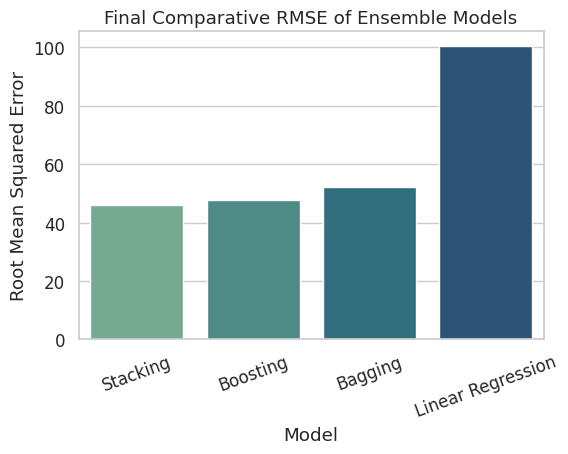

In [ ]:
# Visualization snippet (already runs inside your notebook)
plt.figure(figsize=(6,4))
sns.barplot(data=summary, x="Model", y="RMSE", palette="crest")
plt.title("Final Comparative RMSE of Ensemble Models")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=20)
plt.show()

## Conclusion:
The Stacking Regressor outperforms individual and ensemble models by combining
the strengths of multiple base learners — reducing both bias and variance.

- Bagging reduces model variance (averaging diverse trees).
- Boosting reduces bias (sequential learning on residuals).
- Stacking uses a meta-learner to optimally combine predictions,
  exploiting diversity among models for improved generalization.